In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
df = pd.read_csv(r"C:\Users\veera\Downloads\AI_Job_Market_Trends_2026.csv")

df.head()

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2


In [5]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   job_id                10345 non-null  int64
 1   job_title             10345 non-null  str  
 2   company_size          10345 non-null  str  
 3   company_industry      10345 non-null  str  
 4   country               10345 non-null  str  
 5   remote_type           10345 non-null  str  
 6   experience_level      10345 non-null  str  
 7   years_experience      10345 non-null  int64
 8   education_level       10345 non-null  str  
 9   skills_python         10345 non-null  int64
 10  skills_sql            10345 non-null  int64
 11  skills_ml             10345 non-null  int64
 12  skills_deep_learning  10345 non-null  int64
 13  skills_cloud          10345 non-null  int64
 14  salary                10345 non-null  int64
 15  job_posting_month     10345 non-null  int64
 16  job_posting_yea

job_id                  0
job_title               0
company_size            0
company_industry        0
country                 0
remote_type             0
experience_level        0
years_experience        0
education_level         0
skills_python           0
skills_sql              0
skills_ml               0
skills_deep_learning    0
skills_cloud            0
salary                  0
job_posting_month       0
job_posting_year        0
hiring_urgency          0
job_openings            0
dtype: int64

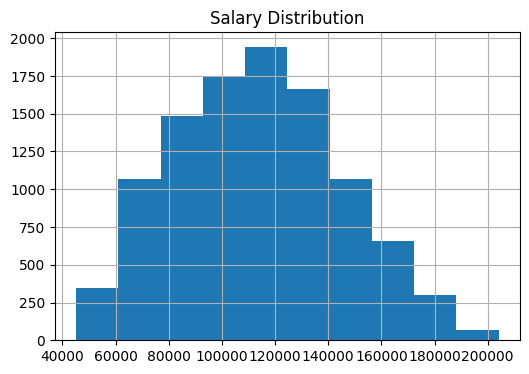

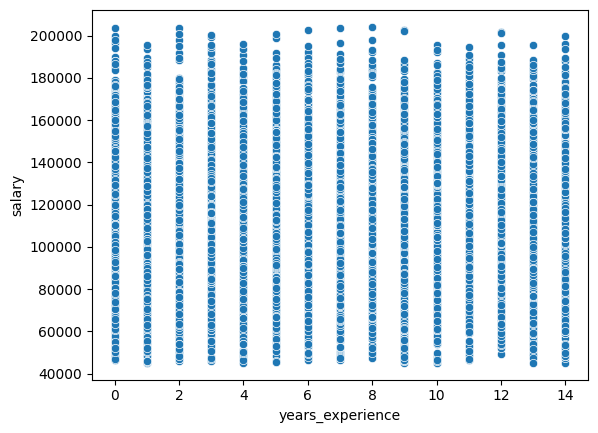

In [6]:
plt.figure(figsize=(6,4))
df['salary'].hist()
plt.title("Salary Distribution")
plt.show()

sns.scatterplot(x='years_experience', y='salary', data=df)
plt.show()

In [7]:
df.drop_duplicates(inplace=True)
df.drop(['job_id'], axis=1, inplace=True)

In [8]:
df['total_skills'] = (
    df['skills_python'] +
    df['skills_sql'] +
    df['skills_ml'] +
    df['skills_deep_learning'] +
    df['skills_cloud']
)

df['exp_squared'] = df['years_experience'] ** 2

In [9]:
X = df.drop('salary', axis=1)
y = df['salary']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

C:\Users\veera\AppData\Local\Temp\ipykernel_12740\1406498323.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


In [12]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)

In [13]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor())
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

In [14]:
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor())
])

dt_pipeline.fit(X_train, y_train)
dt_pred = dt_pipeline.predict(X_test)

In [15]:
def evaluate(y_test, pred, name):
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    
    mean_salary = y_test.mean()
    mae_pct = (mae / mean_salary) * 100
    r2_pct = r2 * 100
    
    print(f"🔹 {name}")
    print(f"MAE: {mae:.2f} ({mae_pct:.2f}%)")
    print(f"Accuracy: {r2_pct:.2f}%")
    print("---------------")

evaluate(y_test, lr_pred, "Linear Regression")
evaluate(y_test, rf_pred, "Random Forest")
evaluate(y_test, dt_pred, "Decision Tree")

🔹 Linear Regression
MAE: 2449.50 (2.18%)
Accuracy: 99.19%
---------------
🔹 Random Forest
MAE: 2599.98 (2.31%)
Accuracy: 99.04%
---------------
🔹 Decision Tree
MAE: 3340.47 (2.97%)
Accuracy: 98.31%
---------------


In [16]:
params = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [10, 20, None]
}

grid = GridSearchCV(rf_pipeline, params, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

In [17]:
final_pred = best_model.predict(X_test)

print("Final MAE:", mean_absolute_error(y_test, final_pred))
print("Final R2:", r2_score(y_test, final_pred))


Final MAE: 2572.1513172324194
Final R2: 0.9907863487001662


In [18]:
pickle.dump(best_model, open("pipeline.pkl", "wb"))

In [19]:
sample = X_test.iloc[[0]]
prediction = best_model.predict(sample)

print("Predicted Salary:", prediction[0])

Predicted Salary: 99965.51923721809
